19/03/2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN

from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

c:\Users\Workstation\Python Environments\mlenv\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
max_features = 10000 # Vocabulary size (only top 10,000 most frequent words will be considered in the dataset)
max_len = 200  # Maximum length of each review (reviews will be truncated or padded to this length)

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences to ensure uniform input length
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

17464789/17464789 [==============================] - 346s 20us/step


In [3]:
sample_review = x_train[0]
print("Sample review (as word indices):", sample_review)

Sample review (as word indices): [   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 447

In [4]:
# Get the word index mapping from Keras's datset
word_index = imdb.get_word_index()

# Create a reverse mapping of the word index so we can convert integers back to words
reverse_word_index = {value : key for key, value in word_index.items()}

# Function to decode a review from its integer sequence back to words
def decode_review(review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in review]) # 'i - 3' because of reserved indices in Keras's dataset

# Display a sample review from the training set
sample_review = x_train[0]
decoded_review = decode_review(sample_review)

print(f"Sample Review (as integers):\n {sample_review}\n")
print(f"Decoded Review (as words):\n {decoded_review}\n")
print(f"Sentiment: {'positive' if y_train[0] == 1 else 'negative'}")

1641221/1641221 [==============================] - 0s 0us/step
Sample Review (as integers):
 [   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4

In [5]:
model = Sequential()
model.add(Embedding(input_dim = max_features,output_dim = 128, input_length=max_len))  # Embedding layer to convert word indices to dense vectors 
model.add(SimpleRNN(100, return_sequences=False))  # Simple RNN layer with 100 units
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          1280000   
                                                                 
 simple_rnn (SimpleRNN)      (None, 100)               22900     
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 1303001 (4.97 MB)
Trainable params: 1303001 (4.97 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
history = model.fit(x_train, y_train, epochs=3, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/3


391/391 [==============================] - 27s 64ms/step - loss: 0.5665 - accuracy: 0.6838 - val_loss: 0.5344 - val_accuracy: 0.7833
Epoch 2/3
391/391 [==============================] - 27s 69ms/step - loss: 0.4981 - accuracy: 0.7545 - val_loss: 0.6646 - val_accuracy: 0.5921
Epoch 3/3
391/391 [==============================] - 21s 53ms/step - loss: 0.5324 - accuracy: 0.7254 - val_loss: 0.6193 - val_accuracy: 0.6391


In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 2)
print('Test accuracy:', test_acc)

782/782 - 8s - loss: 0.6193 - accuracy: 0.6391 - 8s/epoch - 10ms/step
Test accuracy: 0.6390799880027771


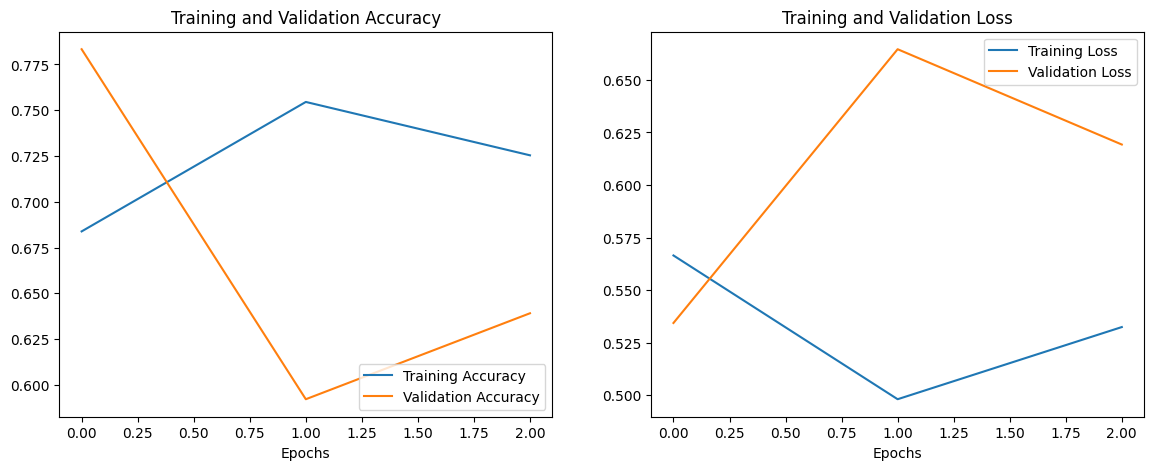

In [9]:
# plotting the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc = 'lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()
